# Netflix Movie Recommendation System using Surprise SVD

## Capstone Project

### Submitted By
Ankit Dagar

---

## Problem Statement

Recommendation systems are widely used by streaming platforms such as Netflix to suggest movies based on users' interests. This project develops a collaborative filtering recommendation system using the Surprise library's Singular Value Decomposition (SVD) algorithm. The model predicts user ratings and recommends movies based on historical user preferences.

---

## Objectives

- Perform exploratory data analysis on the Netflix dataset.
- Build a collaborative filtering recommendation system.
- Implement the Surprise SVD algorithm.
- Predict user ratings.
- Recommend the Top 5 movies with estimated ratings.

In [1]:
!pip -q install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 18.2 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import zipfile
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [3]:
from google.colab import files

uploaded = files.upload()

Saving combined_data_1.txt (1).zip to combined_data_1.txt (1).zip


In [4]:
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file,'r') as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [5]:
uploaded = files.upload()

Saving movie_titles.csv to movie_titles.csv


In [6]:
movies=[]

with open("movie_titles.csv","r",encoding="latin1") as f:

    for line in f:

        parts=line.strip().split(",",2)

        if len(parts)==3:
            movies.append(parts)

movie_titles=pd.DataFrame(
    movies,
    columns=["MovieID","Year","Title"]
)

movie_titles["MovieID"]=movie_titles["MovieID"].astype(int)

movie_titles["Year"]=pd.to_numeric(
    movie_titles["Year"],
    errors="coerce"
)

movie_titles.head()

,MovieID,Year,Title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [7]:
ratings=[]

movie_id=None

limit=800000

count=0

with open("combined_data_1.txt","r") as file:

    for line in file:

        line=line.strip()

        if line.endswith(":"):

            movie_id=int(line[:-1])

        else:

            customer,rating,date=line.split(",")

            ratings.append([
                movie_id,
                int(customer),
                int(rating),
                date
            ])

            count+=1

            if count>=limit:
                break

In [8]:
ratings_df=pd.DataFrame(
    ratings,
    columns=[
        "MovieID",
        "CustomerID",
        "Rating",
        "Date"
    ]
)

ratings_df.head()

,MovieID,CustomerID,Rating,Date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


In [9]:
netflix_df=ratings_df.merge(
    movie_titles,
    on="MovieID",
    how="left"
)

netflix_df.head()

,MovieID,CustomerID,Rating,Date,Year,Title
0,1,1488844,3,2005-09-06,2003.0,Dinosaur Planet
1,1,822109,5,2005-05-13,2003.0,Dinosaur Planet
2,1,885013,4,2005-10-19,2003.0,Dinosaur Planet
3,1,30878,4,2005-12-26,2003.0,Dinosaur Planet
4,1,823519,3,2004-05-03,2003.0,Dinosaur Planet


In [10]:
print(netflix_df.shape)

(800000, 6)


In [12]:
netflix_df.isnull().sum()

,0
MovieID,0
CustomerID,0
Rating,0
Date,0
Year,0
Title,0


In [13]:
netflix_df.describe()

,MovieID,CustomerID,Rating,Year
count,800000.000000,8.000000e+05,800000.000000,800000.000000
mean,107.639271,1.323630e+06,3.615778,1996.311076
std,64.145701,7.645951e+05,1.076039,10.410872
min,1.000000,6.000000e+00,1.000000,1927.000000
25%,30.000000,6.616590e+05,3.000000,1992.000000
50%,111.000000,1.320687e+06,4.000000,2002.000000
75%,175.000000,1.986275e+06,4.000000,2003.000000
max,191.000000,2.649429e+06,5.000000,2005.000000


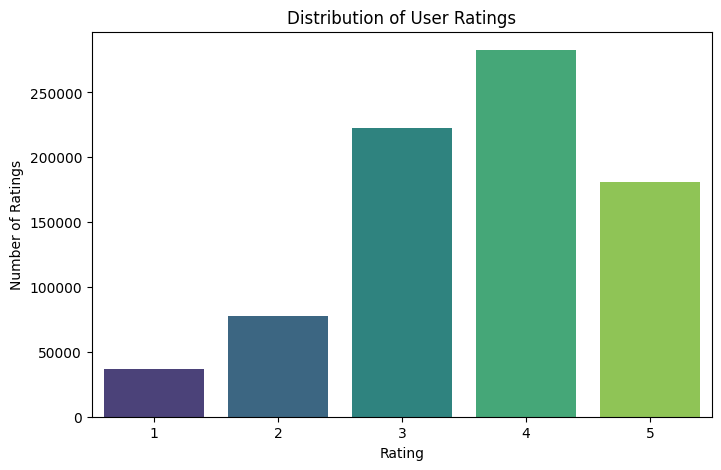

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=netflix_df,
    x="Rating",
    palette="viridis"
)

plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

In [15]:
print("Average Rating :", round(netflix_df["Rating"].mean(),2))

Average Rating : 3.62


In [16]:
rating_percentage = (
    netflix_df["Rating"]
    .value_counts(normalize=True)
    .sort_index()*100
)

rating_percentage

,proportion
Rating,
1,4.588375
2,9.724875
3,27.780500
4,35.333125
5,22.573125


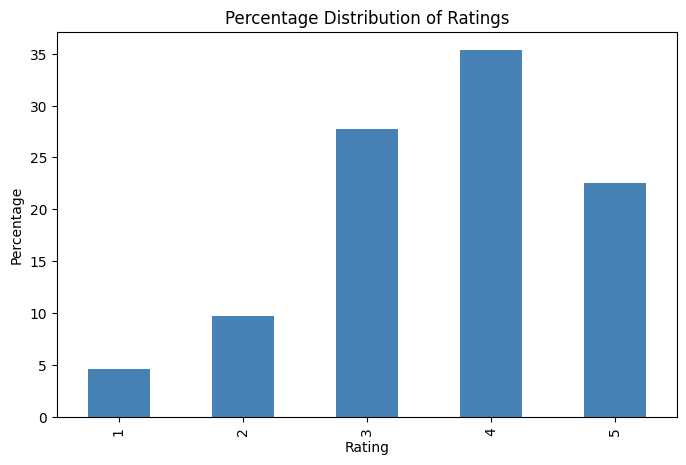

In [17]:
plt.figure(figsize=(8,5))

rating_percentage.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Percentage")

plt.title("Percentage Distribution of Ratings")

plt.show()

In [18]:
top_movies = (
    netflix_df.groupby("Title")["Rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_movies

,Rating
Title,
Something's Gotta Give,118413
Reservoir Dogs,90450
X2: X-Men United,83308
Lilo and Stitch,39752
The Game,38362
Duplex (Widescreen),30127
Sweet November,22194
Death to Smoochy,20049
Rambo: First Blood Part II,19240


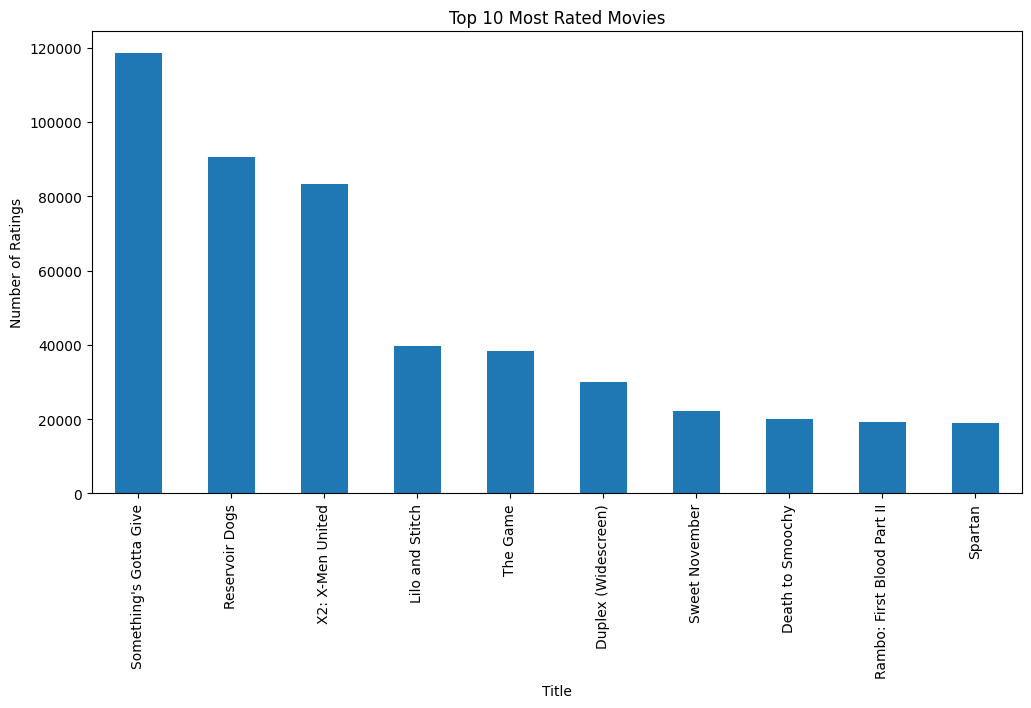

In [19]:
plt.figure(figsize=(12,6))

top_movies.plot(kind="bar")

plt.title("Top 10 Most Rated Movies")

plt.ylabel("Number of Ratings")

plt.show()

In [20]:
movie_stats = netflix_df.groupby("Title").agg(
    Average_Rating=("Rating","mean"),
    Total_Ratings=("Rating","count")
)

movie_stats.head()

,Average_Rating,Total_Ratings
Title,,
6ixtynin9,3.185567,388
7 Seconds,2.903208,7108
8 Man,2.129032,93
A Fishy Story,2.420635,126
A Killer Within,2.657754,374


In [21]:
popular_movies = movie_stats[
    movie_stats["Total_Ratings"]>=50
]

popular_movies.head()

,Average_Rating,Total_Ratings
Title,,
6ixtynin9,3.185567,388
7 Seconds,2.903208,7108
8 Man,2.129032,93
A Fishy Story,2.420635,126
A Killer Within,2.657754,374


In [22]:
popular_movies.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

,Average_Rating,Total_Ratings
Title,,
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material,4.552000,125
Elfen Lied,4.251880,266
Aqua Teen Hunger Force: Vol. 1,4.168650,6890
Invader Zim,4.142599,2216
GTO: Great Teacher Onizuka: Set 2,4.138021,384
Stevie Ray Vaughan and Double Trouble: Live at Montreux 1982 & 1985,4.097872,940
The Chorus,4.092230,9151
I Love Lucy: Season 2,4.090386,2954
ABC Primetime: Mel Gibson's The Passion of the Christ,4.071737,1854


In [23]:
popular_movies.sort_values(
    by="Average_Rating"
).head(10)

,Average_Rating,Total_Ratings
Title,,
Horror Vision,1.634409,93
The Bonesetter,1.675439,114
Sleepover Nightmare,1.954545,176
Iron Monkey 2,1.954545,176
Daydream Obsession,2.051122,802
Blood and Sand,2.096154,104
8 Man,2.129032,93
Spirit Lost,2.131313,99
Darkwolf,2.148148,756


In [24]:
active_users = (
    netflix_df.groupby("CustomerID")["Rating"]
    .count()
    .sort_values(ascending=False)
)

active_users.head(10)

,Rating
CustomerID,
305344,187
387418,186
2439493,179
1664010,167
2118461,155
1932594,101
1461435,100
1639792,98
2056022,93


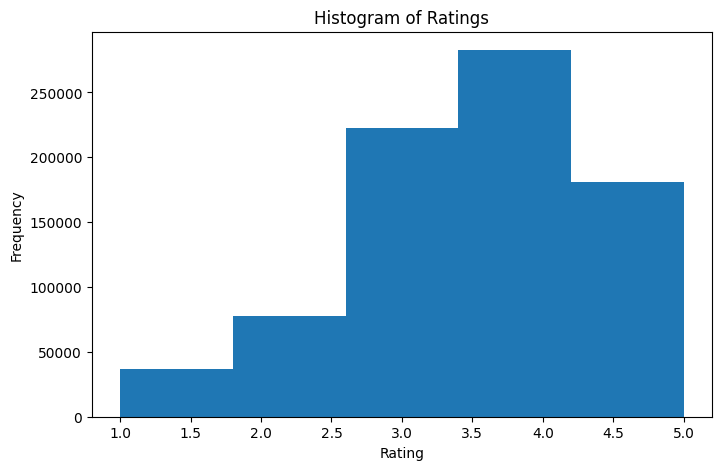

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    netflix_df["Rating"],
    bins=5
)

plt.title("Histogram of Ratings")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

In [26]:
movies_per_year = (
    movie_titles.groupby("Year")["MovieID"]
    .count()
)

movies_per_year.tail()

,MovieID
Year,
2001.0,1184
2002.0,1310
2003.0,1271
2004.0,1436
2005.0,512


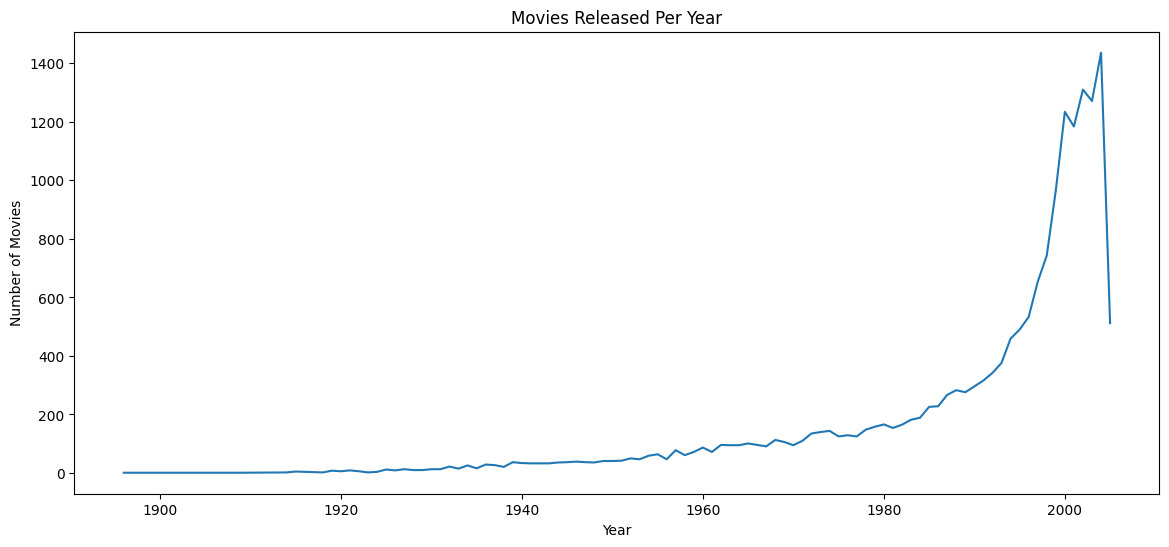

In [27]:
plt.figure(figsize=(14,6))

movies_per_year.plot()

plt.title("Movies Released Per Year")

plt.xlabel("Year")

plt.ylabel("Number of Movies")

plt.show()

In [28]:
movies_per_year.sort_values(
    ascending=False
).head(10)

,MovieID
Year,
2004.0,1436
2002.0,1310
2003.0,1271
2000.0,1234
2001.0,1184
1999.0,965
1998.0,743
1997.0,653
1996.0,533


In [29]:
reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(

    netflix_df[
        [
            "CustomerID",
            "MovieID",
            "Rating"
        ]
    ],

    reader
)

In [30]:
trainset,testset = train_test_split(

    data,

    test_size=0.2,

    random_state=42
)

In [31]:
svd_model = SVD(

    n_factors=100,

    random_state=42
)

In [32]:
svd_model.fit(trainset)

In [33]:
predictions = svd_model.test(testset)

accuracy.rmse(predictions)

RMSE: 0.9903


np.float64(0.9903010624209999)

In [34]:
def recommend_movies(user_id, model, ratings_df, movie_titles, top_n=5):

    watched_movies = ratings_df[
        ratings_df["CustomerID"] == user_id
    ]["MovieID"].unique()

    all_movies = movie_titles["MovieID"].unique()

    unseen_movies = np.setdiff1d(all_movies, watched_movies)

    predictions = []

    for movie in unseen_movies:

        predicted_rating = model.predict(
            uid=user_id,
            iid=movie
        )

        predictions.append(
            (
                movie,
                predicted_rating.est
            )
        )

    predictions = sorted(
        predictions,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for movie_id, score in predictions[:top_n]:

        title = movie_titles[
            movie_titles["MovieID"] == movie_id
        ]["Title"].values

        if len(title) > 0:

            recommendations.append(
                {
                    "MovieID": movie_id,
                    "Title": title[0],
                    "Estimated Rating": round(score, 2)
                }
            )

    return pd.DataFrame(recommendations)

In [35]:
sample_user = netflix_df["CustomerID"].iloc[0]

print("Selected User :", sample_user)

Selected User : 1488844


In [36]:
recommendations = recommend_movies(
    sample_user,
    svd_model,
    ratings_df,
    movie_titles,
    top_n=5
)

recommendations

,MovieID,Title,Estimated Rating
0,85,Elfen Lied,4.29
1,13,Lord of the Rings: The Return of the King: Ext...,4.24
2,52,The Weather Underground,4.15
3,135,GTO: Great Teacher Onizuka: Set 2,4.05
4,25,Inspector Morse 31: Death Is Now My Neighbour,3.96


In [37]:
print("=" * 70)
print("Top 5 Recommended Movies")
print("=" * 70)

for i, row in recommendations.iterrows():

    print(f"{i+1}. {row['Title']}")

    print(f"   Estimated Rating : {row['Estimated Rating']}")

    print()

Top 5 Recommended Movies
1. Elfen Lied
   Estimated Rating : 4.29

2. Lord of the Rings: The Return of the King: Extended Edition: Bonus Material
   Estimated Rating : 4.24

3. The Weather Underground
   Estimated Rating : 4.15

4. GTO: Great Teacher Onizuka: Set 2
   Estimated Rating : 4.05

5. Inspector Morse 31: Death Is Now My Neighbour
   Estimated Rating : 3.96



In [38]:
print(recommendations)

   MovieID                                              Title  \
0       85                                         Elfen Lied   
1       13  Lord of the Rings: The Return of the King: Ext...   
2       52                            The Weather Underground   
3      135                  GTO: Great Teacher Onizuka: Set 2   
4       25      Inspector Morse 31: Death Is Now My Neighbour   

   Estimated Rating  
0              4.29  
1              4.24  
2              4.15  
3              4.05  
4              3.96  


# Conclusion

This project successfully developed a Netflix movie recommendation system using the Surprise library's Singular Value Decomposition (SVD) algorithm.

## Key Outcomes

- Performed data preprocessing and cleaning on the Netflix dataset.
- Conducted exploratory data analysis to understand user rating patterns.
- Built a collaborative filtering recommendation model using Surprise SVD.
- Evaluated the model using Root Mean Squared Error (RMSE).
- Predicted ratings for unseen movies.
- Generated the Top 5 personalized movie recommendations with estimated ratings.

The SVD-based recommendation engine effectively learns user preferences from historical ratings and recommends movies that are likely to match each user's interests.